In [35]:
import numpy as np
import matplotlib.pyplot as plt

## Mean-field theory of equilibrium swelling of polymer networks

and the corresponding affine elastic constants.

In [36]:
from matscipy.calculators.hydrogel.reference_solutions.mean_field_lattices import CROSSLINK_VOLUMES, MeanFieldHydrogelLattice

In [37]:
N = 100 # Number of monomers per chain 
χ =-1 
kuhn =1 

In [38]:
ana = MeanFieldHydrogelLattice(N, 3, CROSSLINK_VOLUMES['graphite'], flory_chi = χ, )

In [39]:
ana.compute_equilibrium_distance()

/home/asanner/Research/2510_coarsegraining_hydrogels/external/matscipy/matscipy/calculators/hydrogel/reference_solutions/mean_field_lattices.py:231: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(self.total_energy, bounds=(0.1 * self.min_radius, 0.9 * self.kuhn * self.chain_nb_monomers), method='bounded', tol=tol)


np.float64(16.898838410236188)

In [40]:
chi = np.linspace(-1.0, 1.5, 100)
reqs = []
energies = []
c44 = []
c11 = []
c12 = []

bulk_modulus = []
shear_modulus = []
youngs_modulus = []
poisson_ratio = []

for c in chi:
    ana = MeanFieldHydrogelLattice(N, 3, CROSSLINK_VOLUMES['graphite'], flory_chi = c, dim=2)
    req = ana.compute_equilibrium_distance()
    reqs.append(req)
    energies.append(ana.total_energy(r=req))
    c44.append(ana.C44(r=req))
    c11.append(ana.C11(r=req))
    c12.append(ana.C12(r=req))

    bulk_modulus.append(ana.bulk_modulus(r=req))
    shear_modulus.append(ana.shear_modulus(r=req))
    youngs_modulus.append(ana.youngs_modulus(r=req))
    poisson_ratio.append(ana.poisson_ratio(r=req))




energies = np.array(energies)
reqs = np.array(reqs)
c44 = np.array(c44)
c11 = np.array(c11)
c12 = np.array(c12)

poisson_ratio = np.array(poisson_ratio)
youngs_modulus = np.array(youngs_modulus)
shear_modulus = np.array(shear_modulus)     
bulk_modulus = np.array(bulk_modulus)


/home/asanner/Research/2510_coarsegraining_hydrogels/external/matscipy/matscipy/calculators/hydrogel/potentials.py:278: UserWarning: Volume fraction φ was clipped: original range [1.33e+00, 1.33e+00] to valid range [1e-10, 0.9999999999]. This may indicate unphysical crosslink densities.
  warnings.warn(f"Volume fraction φ was clipped: original range [{np.min(ϕ_original):.2e}, {np.max(ϕ_original):.2e}] "
/home/asanner/Research/2510_coarsegraining_hydrogels/external/matscipy/matscipy/calculators/hydrogel/potentials.py:294: RuntimeWarning: invalid value encountered in log
  + 1 / v0 * (1 - ϕ) * np.log(1 - ϕ)
/home/asanner/Research/2510_coarsegraining_hydrogels/external/matscipy/matscipy/calculators/hydrogel/potentials.py:278: UserWarning: Volume fraction φ was clipped: original range [2.21e+00, 2.21e+00] to valid range [1e-10, 0.9999999999]. This may indicate unphysical crosslink densities.
  warnings.warn(f"Volume fraction φ was clipped: original range [{np.min(ϕ_original):.2e}, {np.max(

Text(0.5, 0, 'Flory parameter $\\chi$')

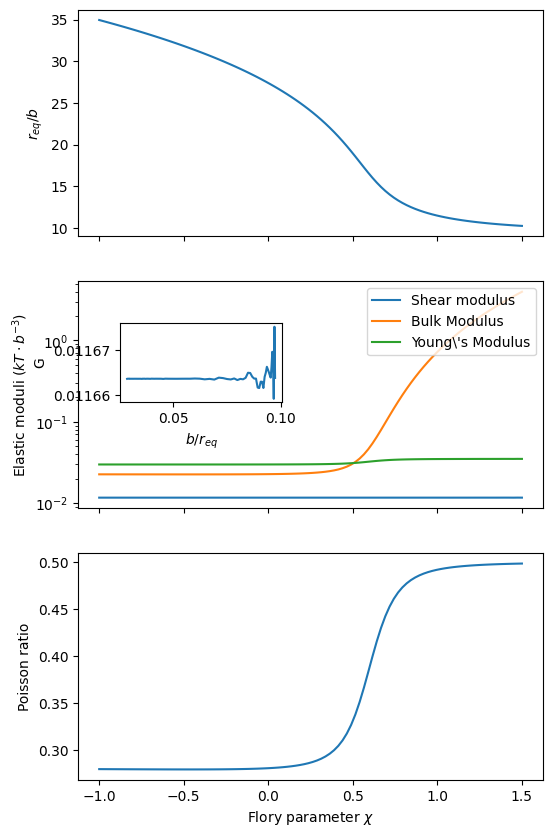

In [41]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(6, 10))
ax = axes[0]

ax.plot(chi, reqs)

# ax.set_xlabel('Flory parameter $\chi$')
ax.set_ylabel('$r_{eq} / b$')

ax = axes[1]
ax.plot(chi, shear_modulus, label=r'Shear modulus')
ax.plot(chi, bulk_modulus, label=r'Bulk Modulus')
ax.plot(chi, youngs_modulus, label=r'Young\'s Modulus')
ax.legend(loc='upper right')

ax.set_ylabel('Elastic moduli $(kT \cdot b^{-3})$')

# ax.set_ylim(top=0.)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

axins = inset_axes(
    ax,
    width="35%",   # relative to parent axis
    height="35%",
    loc="upper left",
    borderpad=3.0
)

ax.set_yscale('log')
# Example content
axins.plot(1/reqs, c44, label=r'Shear modulus')
axins.set_ylabel('G')
axins.set_xlabel(r'$b / r_{eq}$')

ax = axes[2]
ax.plot(chi, poisson_ratio, label=r'Poisson ratio')
ax.set_ylabel('Poisson ratio')

ax.set_xlabel('Flory parameter $\chi$')


In [42]:
from matscipy.calculators.hydrogel.snippets.factory import create_graphite_lattice

In [58]:

# Derived parameters
from matscipy.calculators.hydrogel.calculator import Hydrogel
from matscipy.calculators.hydrogel.potentials import GaussianChain


Re = np.sqrt(N) * kuhn  # RMS end-to-end distance of a free chain
ana = MeanFieldHydrogelLattice(N, 3, CROSSLINK_VOLUMES['graphite'], flory_chi = χ, dim=2)
req_mf = ana.compute_equilibrium_distance()

rc = 6*req_mf  


atoms, molecules = create_graphite_lattice(crosslink_spacing=4* Re, n_cells=4)
calc = Hydrogel(
    cutoff=rc,
    chain_monomers=N,
    kuhn_length=kuhn,
    monomer_volume=ana.v0,
    flory_chi=χ ,
    coordination=ana.coordination,
    molecules=molecules,
    chain=GaussianChain(
        kuhn_length=kuhn,
        chain_monomers=N,
        dim=2,
    ),
    dim=2,
)
atoms.calc = calc

/home/asanner/Research/2510_coarsegraining_hydrogels/external/matscipy/matscipy/calculators/hydrogel/reference_solutions/mean_field_lattices.py:231: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(self.total_energy, bounds=(0.1 * self.min_radius, 0.9 * self.kuhn * self.chain_nb_monomers), method='bounded', tol=tol)


In [59]:
stresses = []
energies = []
distances = []
scale_factors = np.linspace(0.3, 1.10, 100)
cell = atoms.get_cell()

for scale in scale_factors:
    # Scale cell
    new_cell = cell * scale
    atoms.set_cell(new_cell, scale_atoms=True)


    # Record stress and energy
    stress = atoms.get_stress(voigt=True)
    # Ebergy per crosslink
    energy = atoms.get_potential_energy() / len(atoms)
    
    stresses.append(stress)
    energies.append(energy)
    
    bond_lengths = molecules.get_distances(atoms) 
    # print(f'minimum bond distances: {np.min(bond_lengths)}')
    # print(f'maximum bond distances: {np.max(bond_lengths)}')

    distances.append(np.mean(bond_lengths))



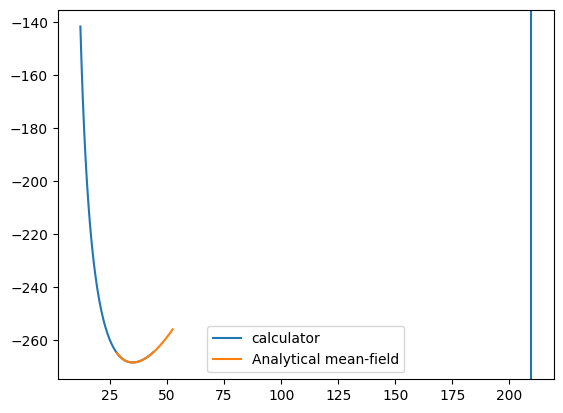

In [60]:
fig, ax = plt.subplots()
ax.plot(distances, energies, label='calculator')
ax.axvline(rc)

rs = np.linspace(0.8, 1.5 ) * ana.compute_equilibrium_distance()

ax.plot(rs, ana.total_energy(r=rs), label='Analytical mean-field')

ax.legend()


In [61]:
molecules.bonds

array([(1, [ 0, 31]), (1, [ 0, 25]), (1, [ 0,  1]), (1, [ 1,  8]),
       (1, [ 1, 10]), (1, [ 2, 25]), (1, [ 2, 27]), (1, [ 2,  3]),
       (1, [ 3, 10]), (1, [ 3, 12]), (1, [ 4, 27]), (1, [ 4, 29]),
       (1, [ 4,  5]), (1, [ 5, 12]), (1, [ 5, 14]), (1, [ 6, 29]),
       (1, [ 6, 31]), (1, [ 6,  7]), (1, [ 7, 14]), (1, [ 7,  8]),
       (1, [ 8,  9]), (1, [ 9, 16]), (1, [ 9, 18]), (1, [10, 11]),
       (1, [11, 18]), (1, [11, 20]), (1, [12, 13]), (1, [13, 20]),
       (1, [13, 22]), (1, [14, 15]), (1, [15, 22]), (1, [15, 16]),
       (1, [16, 17]), (1, [17, 24]), (1, [17, 26]), (1, [18, 19]),
       (1, [19, 26]), (1, [19, 28]), (1, [20, 21]), (1, [21, 28]),
       (1, [21, 30]), (1, [22, 23]), (1, [23, 30]), (1, [23, 24]),
       (1, [24, 25]), (1, [26, 27]), (1, [28, 29]), (1, [30, 31])],
      dtype=[('type', '<i4'), ('atoms', '<i4', (2,))])

In [64]:
from pathlib import Path
import nglview as nv

def write_pdb_conect(atoms, bonds, filename="network.pdb"):
    filename = Path(filename)

    # Build adjacency for CONECT records
    adj = [[] for _ in range(len(atoms))]
    for i, j in bonds:
        adj[i].append(j)
        adj[j].append(i)

    with filename.open("w") as f:
        f.write("MODEL        1\n")
        for aidx, atom in enumerate(atoms, start=1):  # PDB is 1-based
            x, y, z = atom.position
            sym = (atom.symbol or "X")[:2]
            f.write(
                f"ATOM  {aidx:5d} {sym:<4s} NET A   1    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00          {sym:>2s}\n"
            )

        # CONECT lines (split into chunks of 4 partners per line)
        for i0 in range(len(atoms)):
            partners = adj[i0]
            if not partners:
                continue
            i_ser = i0 + 1
            p_ser = [p + 1 for p in partners]
            for k in range(0, len(p_ser), 4):
                chunk = p_ser[k:k+4]
                f.write("CONECT" + f"{i_ser:5d}" + "".join(f"{p:5d}" for p in chunk) + "\n")

        f.write("ENDMDL\nEND\n")

    return str(filename)
# molecules.bonds is a structured array with field 'atoms'
bonds = [tuple(map(int, pair)) for pair in molecules.bonds["atoms"]]
# or as an ndarray:
# bonds = molecules.bonds["atoms"].astype(int)


def suppress_pbc_crossing_bonds(atoms, bonds, atol=1e-10):
    """
    Return bonds that do NOT cross the periodic boundary, judged by whether
    the direct displacement is already the minimum-image displacement.

    atol: numerical tolerance on the displacement difference.
    """
    cell = atoms.cell.array
    pbc = atoms.pbc
    pos = atoms.get_positions()

    kept = []
    for i, j in bonds:
        d = pos[j] - pos[i]
        d_mic, _shift = find_mic(d, cell, pbc=pbc)
        if np.linalg.norm(d - d_mic) <= atol:
            kept.append((i, j))
    return kept


pdb_path = write_pdb_conect(atoms, suppress_pbc_crossing_bonds(atoms, bonds), "network.pdb")
# pdb_path = write_pdb_conect(atoms, bonds, "network.pdb")

view = nv.show_file(pdb_path)
view.clear_representations()
view.add_representation("ball+stick", radiusScale=10)
view

NGLWidget()